# Notebook 01 — Exploratory Data Analysis

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — ULB Machine Learning Group  
**Task:** Semi-supervised anomaly detection. VAE trained on normal transactions only.  

| Feature group | Columns | Notes |
|---|---|---|
| PCA components | V1 – V28 | Anonymised; already zero-centred |
| Raw features | Time, Amount | Require scaling before training |
| Label | Class | 0 = Normal, 1 = Fraud |

## 1. Imports & Load

In [2]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import src.config as cfg

RAW_CSV = cfg.RAW_CSV
TARGET  = cfg.TARGET_COL   # 'Class'

df = pd.read_csv(RAW_CSV)
print(f'Shape  : {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Dtypes :\n{df.dtypes.value_counts()}')

Shape  : (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Dtypes :
float64    30
int64       1
Name: count, dtype: int64


## 2. Dataset Overview

In [3]:
print('--- Head ---')
display(df.head(3))

print('\n--- Basic statistics ---')
display(df[['Time', 'Amount']].describe().round(2))

missing = df.isnull().sum().sum()
print(f'\nMissing values: {missing}  ({"none" if missing == 0 else "NEEDS IMPUTATION"})')

--- Head ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0



--- Basic statistics ---


,Time,Amount
count,284807.00,284807.00
mean,94813.86,88.35
std,47488.15,250.12
min,0.00,0.00
25%,54201.50,5.60
50%,84692.00,22.00
75%,139320.50,77.16
max,172792.00,25691.16



Missing values: 0  (none)


## 3. Class Distribution — Extreme Imbalance

Normal (0) : 284,315  (99.8273%)
Fraud  (1) :     492  (0.1727%)
Total      : 284,807
Imbalance ratio (normal:fraud) = 578:1


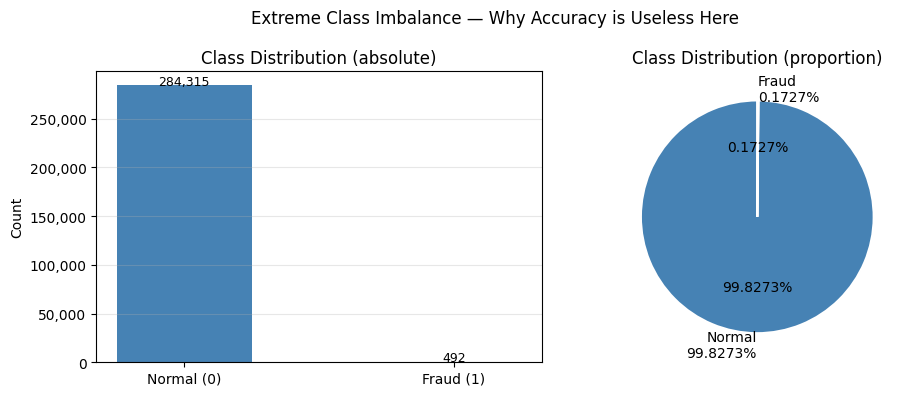

In [4]:
counts      = df[TARGET].value_counts().sort_index()
fraud_rate  = counts[1] / len(df) * 100

print(f'Normal (0) : {counts[0]:>7,}  ({100 - fraud_rate:.4f}%)')
print(f'Fraud  (1) : {counts[1]:>7,}  ({fraud_rate:.4f}%)')
print(f'Total      : {len(df):>7,}')
print(f'Imbalance ratio (normal:fraud) = {counts[0] / counts[1]:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
ax = axes[0]
ax.bar(['Normal (0)', 'Fraud (1)'], counts.values,
       color=['steelblue', 'crimson'], width=0.5)
ax.set_ylabel('Count')
ax.set_title('Class Distribution (absolute)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Pie chart
ax = axes[1]
ax.pie(counts.values,
       labels=[f'Normal\n{100-fraud_rate:.4f}%', f'Fraud\n{fraud_rate:.4f}%'],
       colors=['steelblue', 'crimson'],
       autopct='%1.4f%%', startangle=90,
       wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
ax.set_title('Class Distribution (proportion)')

plt.suptitle('Extreme Class Imbalance — Why Accuracy is Useless Here', fontsize=12)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Time & Amount Distributions

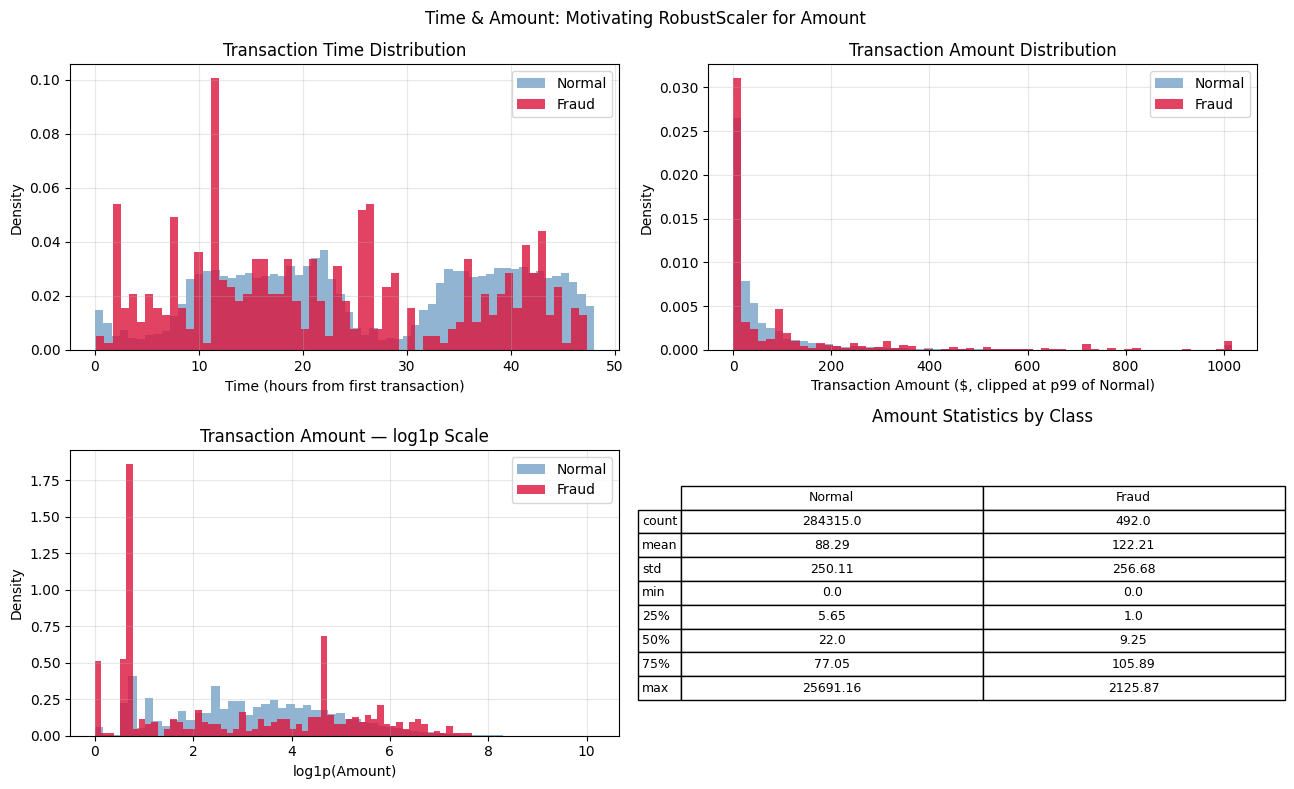

In [5]:
normal = df[df[TARGET] == 0]
fraud  = df[df[TARGET] == 1]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Time — full distribution
ax = axes[0, 0]
ax.hist(normal['Time'] / 3600, bins=60, alpha=0.6,
        color='steelblue', density=True, label='Normal')
ax.hist(fraud['Time']  / 3600, bins=60, alpha=0.8,
        color='crimson',   density=True, label='Fraud')
ax.set_xlabel('Time (hours from first transaction)')
ax.set_ylabel('Density')
ax.set_title('Transaction Time Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Amount — log scale
ax = axes[0, 1]
ax.hist(normal['Amount'].clip(upper=normal['Amount'].quantile(0.99)),
        bins=60, alpha=0.6, color='steelblue', density=True, label='Normal')
ax.hist(fraud['Amount'].clip(upper=normal['Amount'].quantile(0.99)),
        bins=60, alpha=0.8, color='crimson',   density=True, label='Fraud')
ax.set_xlabel('Transaction Amount ($, clipped at p99 of Normal)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Amount — log1p
ax = axes[1, 0]
ax.hist(np.log1p(normal['Amount']), bins=60, alpha=0.6,
        color='steelblue', density=True, label='Normal')
ax.hist(np.log1p(fraud['Amount']),  bins=60, alpha=0.8,
        color='crimson',   density=True, label='Fraud')
ax.set_xlabel('log1p(Amount)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount — log1p Scale')
ax.legend()
ax.grid(alpha=0.3)

# Amount stats table
ax = axes[1, 1]
ax.axis('off')
stats = pd.DataFrame({
    'Normal':  normal['Amount'].describe().round(2),
    'Fraud':   fraud['Amount'].describe().round(2),
})
tbl = ax.table(cellText=stats.values.tolist(),
               rowLabels=stats.index,
               colLabels=stats.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.4)
ax.set_title('Amount Statistics by Class', pad=20)

plt.suptitle('Time & Amount: Motivating RobustScaler for Amount', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/time_amount_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. PCA Feature Distributions (V1–V28)

Box plots show the median and IQR per feature split by class.
Features where the fraud box is far from the normal box carry discriminative signal.

Top 10 most discriminative PCA features (|fraud_mean - normal_mean|):
V3     7.0455
V14    6.9838
V17    6.6774
V12    6.2702
V10    5.6867
V7     5.5784
V1     4.7802
V4     4.5499
V16    4.1471
V11    3.8067


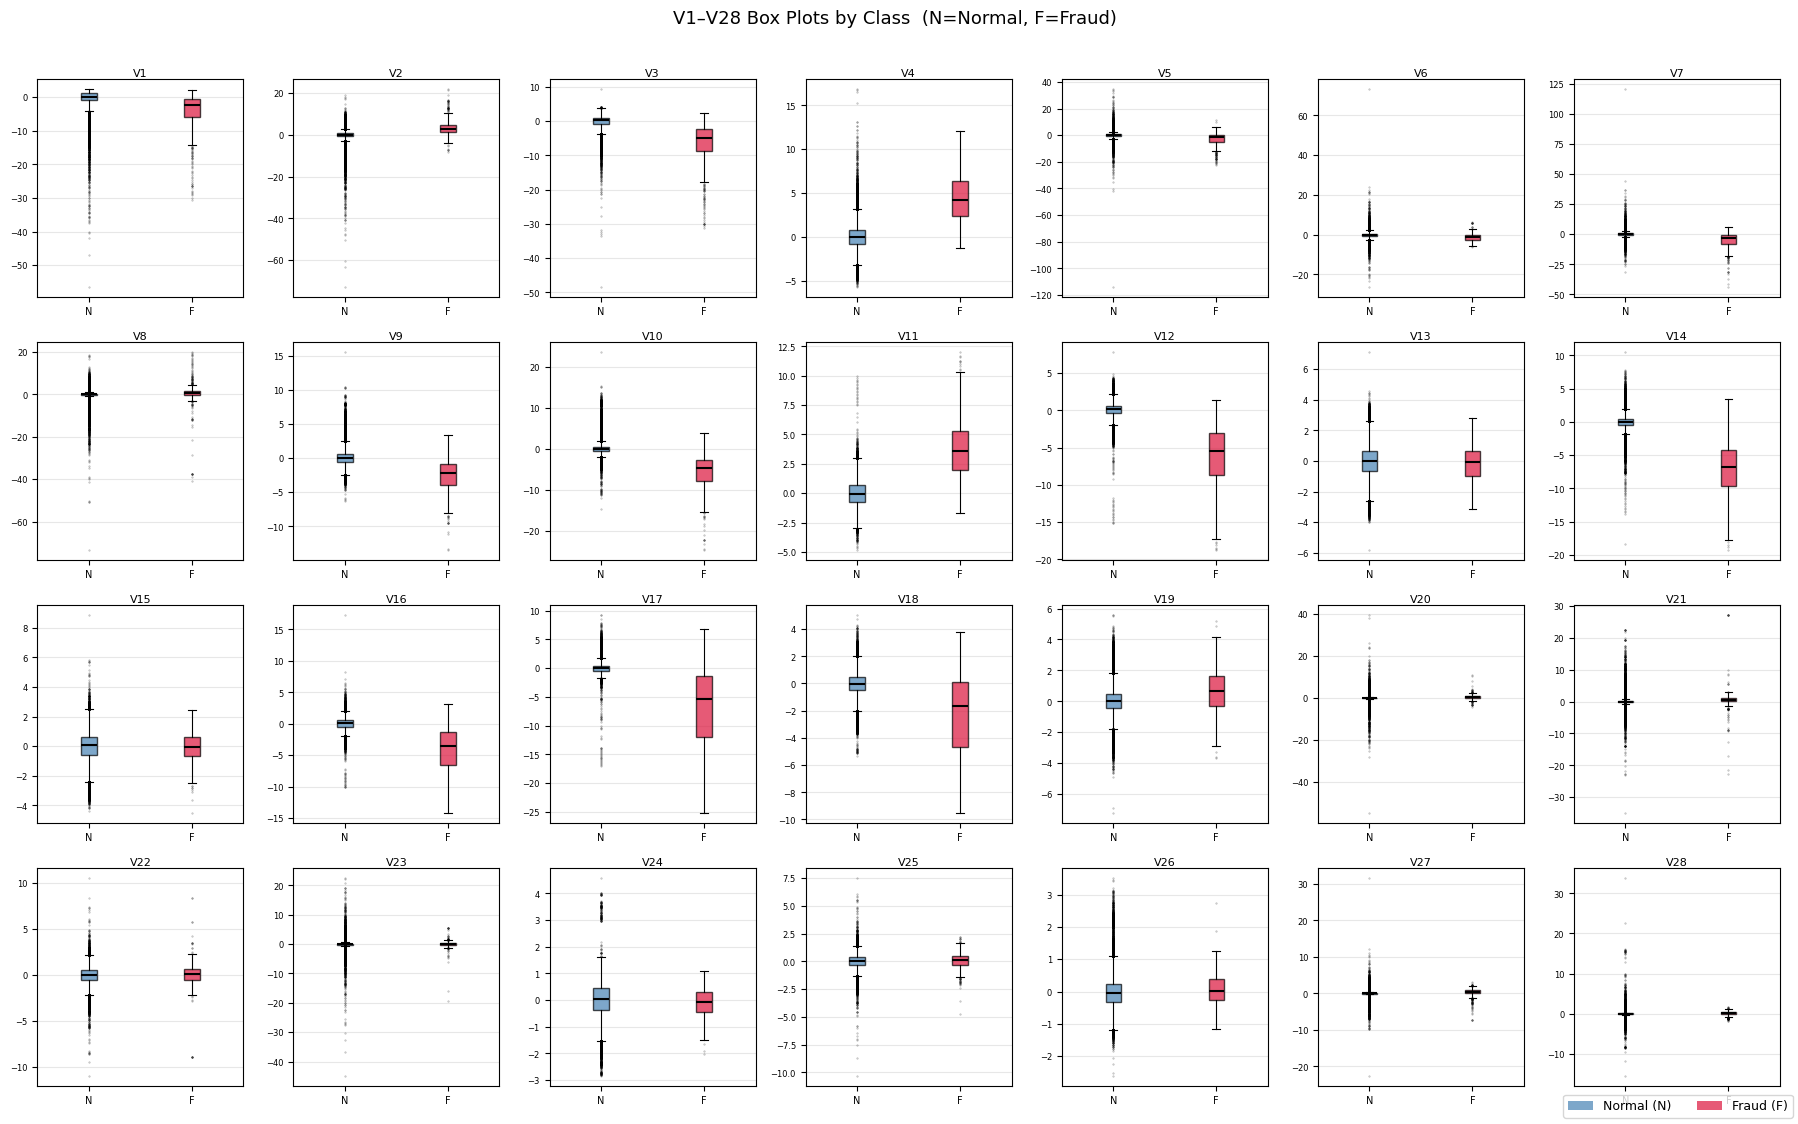

In [6]:
v_cols = [f'V{i}' for i in range(1, 29)]

# Mean absolute deviation from 0 per feature, split by class
normal_means = normal[v_cols].mean()
fraud_means  = fraud[v_cols].mean()
separation   = (fraud_means - normal_means).abs().sort_values(ascending=False)

print('Top 10 most discriminative PCA features (|fraud_mean - normal_mean|):')
print(separation.head(10).round(4).to_string())

fig, axes = plt.subplots(4, 7, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(v_cols):
    ax = axes[i]
    data = [normal[col].values, fraud[col].values]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.5},
                    flierprops={'marker': '.', 'markersize': 1, 'alpha': 0.3},
                    whiskerprops={'linewidth': 0.8},
                    capprops={'linewidth': 0.8})
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('crimson')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(col, fontsize=8, pad=2)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['N', 'F'], fontsize=7)
    ax.tick_params(axis='y', labelsize=6)
    ax.grid(axis='y', alpha=0.3)

# Hide the 28th+1 unused subplot
for j in range(len(v_cols), len(axes)):
    axes[j].set_visible(False)

fig.legend(
    handles=[
        plt.Rectangle((0,0),1,1, fc='steelblue', alpha=0.7, label='Normal (N)'),
        plt.Rectangle((0,0),1,1, fc='crimson',   alpha=0.7, label='Fraud (F)'),
    ],
    loc='lower right', fontsize=9, ncol=2,
)
plt.suptitle('V1–V28 Box Plots by Class  (N=Normal, F=Fraud)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/pca_feature_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Discriminative Features — Histogram Overlay

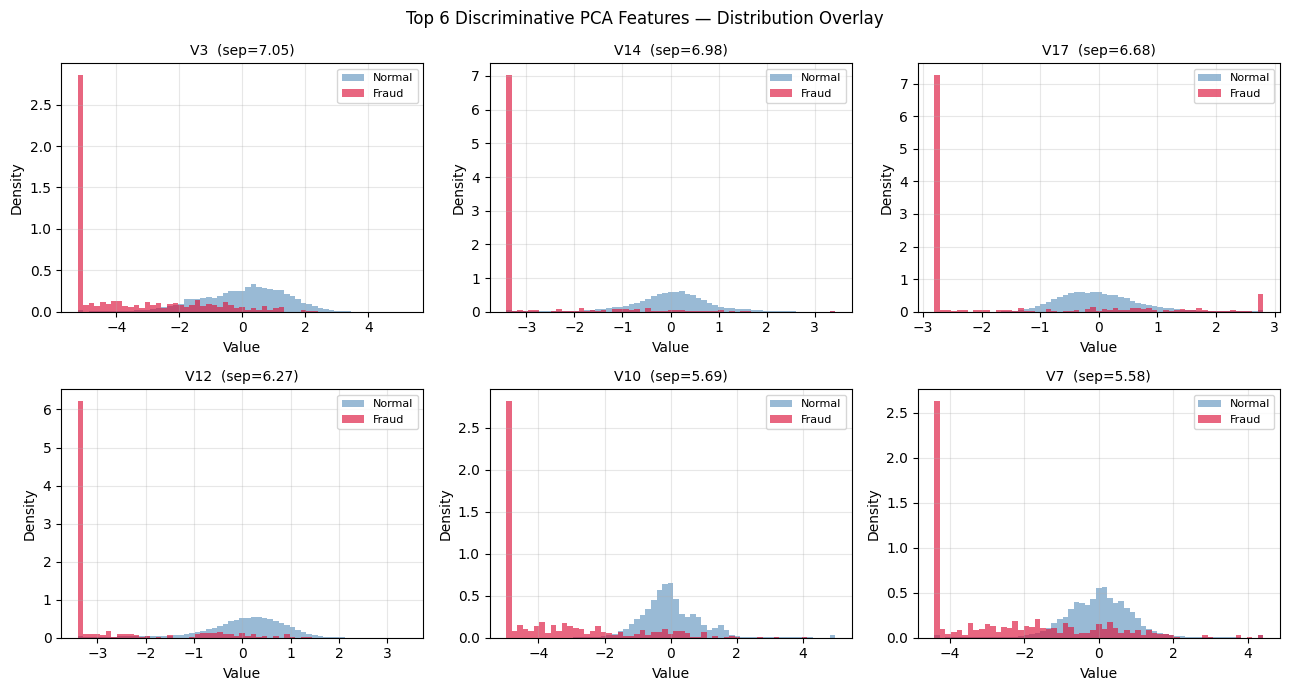

In [7]:
top_feats = separation.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(top_feats):
    ax   = axes[i]
    clip = max(abs(df[col].quantile(0.005)), abs(df[col].quantile(0.995)))
    bins = np.linspace(-clip, clip, 60)
    ax.hist(normal[col].clip(-clip, clip), bins=bins, alpha=0.55,
            density=True, color='steelblue', label='Normal')
    ax.hist(fraud[col].clip(-clip, clip),  bins=bins, alpha=0.65,
            density=True, color='crimson',   label='Fraud')
    ax.set_title(f'{col}  (sep={separation[col]:.2f})', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Top 6 Discriminative PCA Features — Distribution Overlay', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/top_features_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Correlation Heatmap

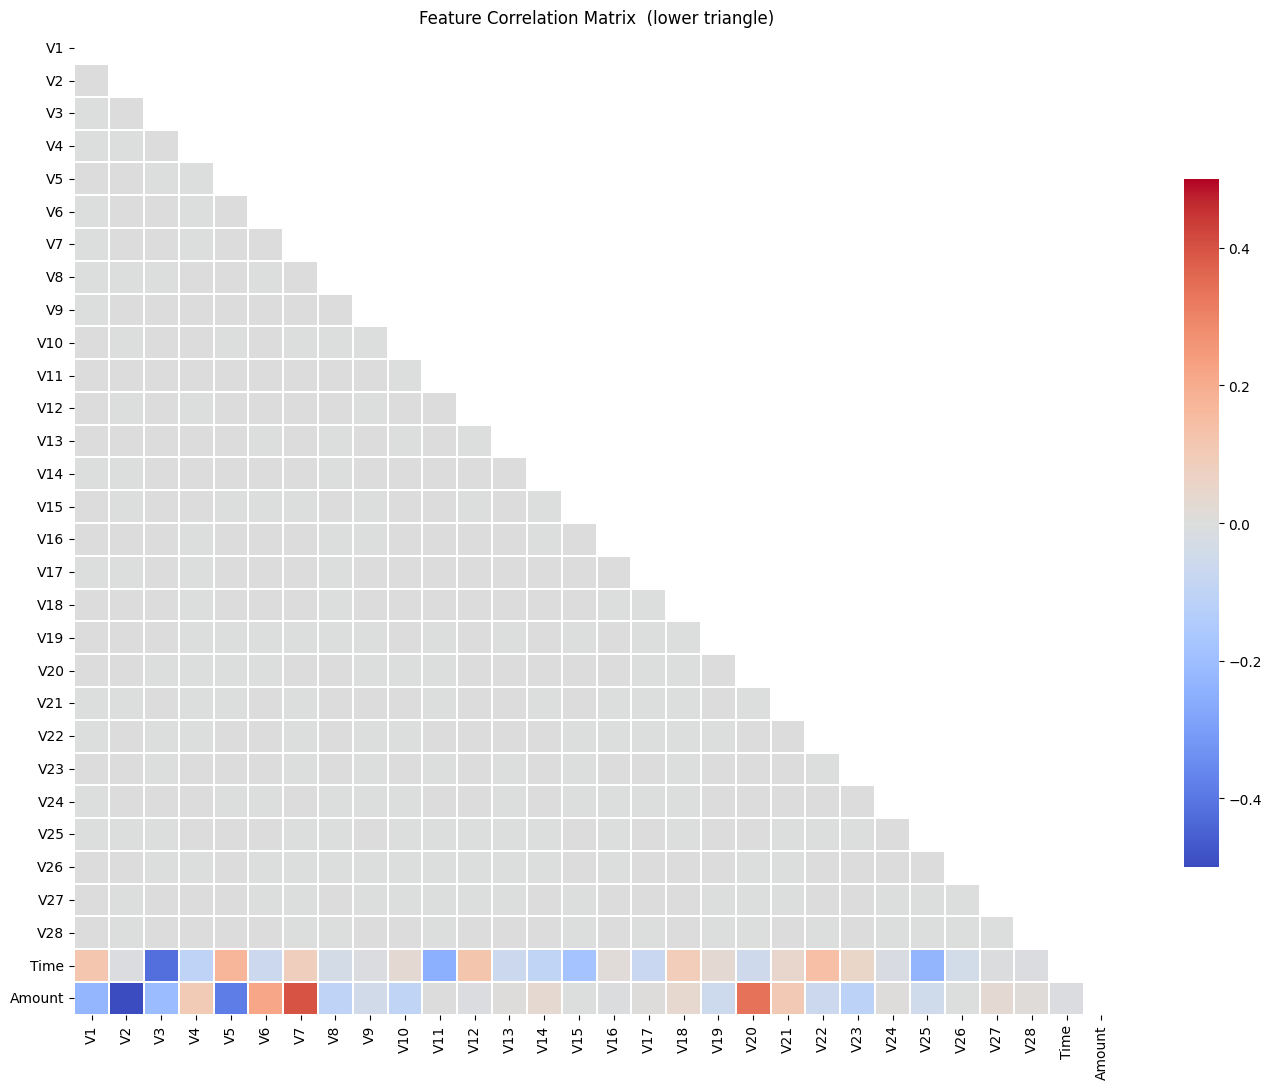

High correlations |r| > 0.5:
  V2 vs Amount: r=-0.531


In [8]:
# PCA features are orthogonal by construction — expect near-zero correlation.
# Any strong correlation would indicate data leakage or pre-processing issues.
corr = df[v_cols + ['Time', 'Amount']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask,
    cmap='coolwarm', vmin=-0.5, vmax=0.5,
    annot=False, linewidths=0.3, ax=ax,
    cbar_kws={'shrink': 0.7},
)
ax.set_title('Feature Correlation Matrix  (lower triangle)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag any unexpectedly high correlations
high = [
    (corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3))
    for i in range(len(corr))
    for j in range(i + 1, len(corr))
    if abs(corr.iloc[i, j]) > 0.5
]
if high:
    print('High correlations |r| > 0.5:')
    for a, b, r in sorted(high, key=lambda x: -abs(x[2])):
        print(f'  {a} vs {b}: r={r}')
else:
    print('No correlations |r| > 0.5 — features are orthogonal as expected.')

## 8. Scaling Motivation

In [9]:
print('Why scaling is needed before VAE training:')
print()

stats = df[['Time', 'Amount'] + v_cols[:5]].agg(['mean', 'std', 'min', 'max']).round(2)
display(stats)

print()
print(f'  Time   range : [{df["Time"].min():.0f}, {df["Time"].max():.0f}]  '
      f'→ StandardScaler (uniform, no outliers)')
print(f'  Amount range : [{df["Amount"].min():.2f}, {df["Amount"].max():.2f}]  '
      f'→ RobustScaler   (right-skewed, extreme outliers)')
print(f'  V1–V28 std   : ~{df[v_cols].std().mean():.2f} on average  '
      f'→ no scaling needed (already ~N(0,1))')

Why scaling is needed before VAE training:



,Time,Amount,V1,V2,V3,V4,V5
mean,94813.86,88.35,0.00,0.00,-0.00,0.00,0.00
std,47488.15,250.12,1.96,1.65,1.52,1.42,1.38
min,0.00,0.00,-56.41,-72.72,-48.33,-5.68,-113.74
max,172792.00,25691.16,2.45,22.06,9.38,16.88,34.80



  Time   range : [0, 172792]  → StandardScaler (uniform, no outliers)
  Amount range : [0.00, 25691.16]  → RobustScaler   (right-skewed, extreme outliers)
  V1–V28 std   : ~0.98 on average  → no scaling needed (already ~N(0,1))


## 9. EDA Summary

In [10]:
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)
print(f'Total transactions  : {len(df):,}')
print(f'Normal (Class=0)    : {counts[0]:,}  ({100 - fraud_rate:.4f}%)')
print(f'Fraud  (Class=1)    : {counts[1]:,}  ({fraud_rate:.4f}%)')
print(f'Imbalance ratio     : {counts[0]/counts[1]:.0f}:1')
print(f'Missing values      : {missing}')
print(f'Features            : 30  (Time, V1–V28, Amount)')
print()
print('Preprocessing decisions:')
print('  Time   → StandardScaler')
print('  Amount → RobustScaler (heavy right tail)')
print('  V1–V28 → no scaling (PCA-transformed, already ~N(0,1))')
print()
print('Semi-supervised split strategy:')
print('  X_train : 80% of Class 0 only  — VAE sees no fraud during training')
print('  X_val   : 20% of Class 0  +  100% of Class 1')
print()
print('Key evaluation metrics:')
print('  AUPRC (primary)  — invariant to class imbalance, penalises missed fraud')
print('  AUROC (secondary) — threshold-free ranking metric')
print('  Accuracy          — MISLEADING at 0.17% fraud rate, do not use')
print('=' * 60)

EDA SUMMARY
Total transactions  : 284,807
Normal (Class=0)    : 284,315  (99.8273%)
Fraud  (Class=1)    : 492  (0.1727%)
Imbalance ratio     : 578:1
Missing values      : 0
Features            : 30  (Time, V1–V28, Amount)

Preprocessing decisions:
  Time   → StandardScaler
  Amount → RobustScaler (heavy right tail)
  V1–V28 → no scaling (PCA-transformed, already ~N(0,1))

Semi-supervised split strategy:
  X_train : 80% of Class 0 only  — VAE sees no fraud during training
  X_val   : 20% of Class 0  +  100% of Class 1

Key evaluation metrics:
  AUPRC (primary)  — invariant to class imbalance, penalises missed fraud
  AUROC (secondary) — threshold-free ranking metric
  Accuracy          — MISLEADING at 0.17% fraud rate, do not use
